## Base matemática

O problema é uma classificação binária supervisionada. Cada passageiro $i$ tem um vetor de atributos $x_i \in \mathbb{R}^d$ (classe, sexo, porto de embarque, idade, número de irmãos/cônjuges, número de pais/filhos e tarifa) e um rótulo $y_i \in \{0, 1\}$, com 1 = sobreviveu. O modelo estima

$$p_i = P(y_i = 1 \mid x_i)$$

e a previsão é $\hat{y}_i = \mathbf{1}[p_i \ge 0.5]$. O dataset tem 891 passageiros, e 38% deles sobreviveram. A divisão treino/teste (80/20) é estratificada, então os dois conjuntos mantêm essa proporção.

### 1. Pré-processamento

Imputação: `Age` tem 177 valores faltantes (20%) e `Embarked` tem 2. Valores numéricos faltantes recebem a mediana da coluna, e valores categóricos faltantes recebem a moda. A mediana é menos afetada por valores extremos do que a média, o que importa em colunas assimétricas como `Fare`.

$$\tilde{x}_{ij} = \begin{cases} x_{ij} & \text{se observado} \\ \text{mediana}(X_j) & \text{se faltante} \end{cases}$$

Padronização (z-score) com `StandardScaler`:

$$x' = \frac{x - \mu}{\sigma}$$

Os splits de uma árvore dependem só da ordem dos valores de cada feature, e a padronização não altera essa ordem. Por isso o `StandardScaler` não muda o resultado do XGBoost. Ele só faria diferença se o modelo fosse trocado por um modelo linear.

One-hot encoding: cada variável categórica vira um vetor de indicadores. Por exemplo, $\text{Pclass} = 3 \mapsto (0,\ 0,\ 1)$ e $\text{Sex} = \text{female} \mapsto (1,\ 0)$.

### 2. Modelo: soma de árvores

O XGBoost (Chen & Guestrin, 2016) implementa gradient boosting com árvores de decisão (Friedman, 2001). O escore de um exemplo é um valor inicial $F_0$ mais a soma das saídas de $K$ árvores de regressão. Cada árvore $f_k$ devolve o peso $w$ da folha em que $x$ cai:

$$F(x_i) = F_0 + \sum_{k=1}^{K} \eta\, f_k(x_i), \qquad f_k(x) = w_{q(x)}, \quad q : \mathbb{R}^d \to \{1, \dots, T\}$$

$F$ está na escala de log-odds, e a sigmoide converte o escore em probabilidade:

$$p_i = \sigma\big(F(x_i)\big) = \frac{1}{1 + e^{-F(x_i)}} \quad \Longleftrightarrow \quad F(x_i) = \log \frac{p_i}{1 - p_i}$$

### 3. Log-loss

A função de perda é a entropia cruzada binária:

$$\ell(y_i, p_i) = -\big[\, y_i \log p_i + (1 - y_i) \log(1 - p_i) \,\big]$$

Usando $\sigma'(F) = \sigma(F)\,\big(1 - \sigma(F)\big)$, as derivadas em relação ao escore $F$ são:

$$g_i = \frac{\partial \ell}{\partial F} = p_i - y_i, \qquad h_i = \frac{\partial^2 \ell}{\partial F^2} = p_i\,(1 - p_i)$$

$g_i$ é a diferença entre a probabilidade prevista e o rótulo. $h_i$ vale no máximo $0.25$, em $p_i = 0.5$, e se aproxima de 0 quando $p_i$ se aproxima de 0 ou de 1.

### 4. Objetivo com regularização

O XGBoost soma à perda uma penalidade para cada árvore, que depende do número de folhas $T$ e dos pesos das folhas $w$:

$$\mathcal{L} = \sum_{i=1}^{n} \ell(y_i, p_i) + \sum_{k=1}^{K} \Omega(f_k), \qquad \Omega(f) = \gamma T + \frac{1}{2} \lambda \lVert w \rVert^2$$

Os valores padrão são $\lambda = 1$ e $\gamma = 0$.

### 5. Construção de cada árvore

Na iteração $t$ o modelo $F^{(t-1)}$ já está fixo, e o algoritmo procura a árvore $f_t$ que mais reduz a perda. A expansão de Taylor de segunda ordem de $\ell$ em torno do escore atual dá:

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \Big[\, g_i\, f_t(x_i) + \frac{1}{2} h_i\, f_t^2(x_i) \Big] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2 + \text{const.}$$

Seja $I_j$ o conjunto de exemplos na folha $j$, com $G_j = \sum_{i \in I_j} g_i$ e $H_j = \sum_{i \in I_j} h_i$. Agrupando os termos por folha, a expressão vira uma soma de parábolas, uma para cada $w_j$:

$$\mathcal{L}^{(t)} \approx \sum_{j=1}^{T} \Big[\, G_j w_j + \frac{1}{2} (H_j + \lambda)\, w_j^2 \Big] + \gamma T$$

Igualando a derivada a zero, $\dfrac{\partial \mathcal{L}^{(t)}}{\partial w_j} = G_j + (H_j + \lambda)\, w_j = 0$, o peso ótimo de cada folha é:

$$w_j^* = -\frac{G_j}{H_j + \lambda}$$

É um passo de Newton (gradiente dividido pela segunda derivada) com $\lambda$ somado ao denominador. Substituindo $w_j^*$ na expressão, o valor do objetivo para a árvore é $-\frac{1}{2} \sum_j \frac{G_j^2}{H_j + \lambda} + \gamma T$.

### 6. Escolha dos splits

Em cada nó, o algoritmo testa as features e os limiares possíveis e calcula o ganho de dividir o nó em esquerda ($L$) e direita ($R$):

$$\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma$$

O split escolhido é o de maior ganho. O gráfico de importância no notebook usa `importance_type="gain"`: para cada feature, a média desse ganho nos splits que usam a feature, normalizada para que a soma seja 1.

### 7. Learning rate e hiperparâmetros

Cada árvore nova é multiplicada por $\eta$ antes de ser somada ao modelo:

$$F^{(t)}(x) = F^{(t-1)}(x) + \eta\, f_t(x)$$

| Hiperparâmetro | Valor | Efeito |
|---|---|---|
| `n_estimators` ($K$) | 200 | número de árvores |
| `max_depth` | 4 | até $2^4 = 16$ folhas por árvore e interações entre até 4 variáveis |
| `learning_rate` ($\eta$) | 0.05 | cada árvore altera pouco o escore; são necessárias mais árvores e o risco de overfitting diminui |

### 8. Métricas

Com $TP$, $TN$, $FP$ e $FN$ da matriz de confusão (classe positiva = sobreviveu):

$$\text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}, \qquad \text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

### Referências

- Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. KDD. [arXiv:1603.02754](https://arxiv.org/abs/1603.02754)
- Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. Annals of Statistics, 29(5). [doi:10.1214/aos/1013203451](https://doi.org/10.1214/aos/1013203451)
- Documentação do XGBoost: [Introduction to Boosted Trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)

## Mathematical background

This is a supervised binary classification problem. Each passenger $i$ has a feature vector $x_i \in \mathbb{R}^d$ (class, sex, port of embarkation, age, number of siblings/spouses, number of parents/children and fare) and a label $y_i \in \{0, 1\}$, with 1 = survived. The model estimates

$$p_i = P(y_i = 1 \mid x_i)$$

and the prediction is $\hat{y}_i = \mathbf{1}[p_i \ge 0.5]$. The dataset has 891 passengers, and 38% of them survived. The train/test split (80/20) is stratified, so both sets keep that ratio.

### 1. Preprocessing

Imputation: `Age` has 177 missing values (20%) and `Embarked` has 2. Missing numeric values get the column median, and missing categorical values get the mode. The median is less affected by extreme values than the mean, which matters for skewed columns such as `Fare`.

$$\tilde{x}_{ij} = \begin{cases} x_{ij} & \text{if observed} \\ \text{median}(X_j) & \text{if missing} \end{cases}$$

Standardization (z-score) with `StandardScaler`:

$$x' = \frac{x - \mu}{\sigma}$$

Tree splits depend only on the order of each feature's values, and standardization does not change that order. So `StandardScaler` does not change the XGBoost result. It would only matter if the model were replaced by a linear model.

One-hot encoding: each categorical variable becomes a vector of indicators. For example, $\text{Pclass} = 3 \mapsto (0,\ 0,\ 1)$ and $\text{Sex} = \text{female} \mapsto (1,\ 0)$.

### 2. Model: a sum of trees

XGBoost (Chen & Guestrin, 2016) implements gradient boosting with decision trees (Friedman, 2001). The score of an example is an initial value $F_0$ plus the sum of the outputs of $K$ regression trees. Each tree $f_k$ returns the weight $w$ of the leaf that $x$ falls into:

$$F(x_i) = F_0 + \sum_{k=1}^{K} \eta\, f_k(x_i), \qquad f_k(x) = w_{q(x)}, \quad q : \mathbb{R}^d \to \{1, \dots, T\}$$

$F$ is on the log-odds scale, and the sigmoid converts the score into a probability:

$$p_i = \sigma\big(F(x_i)\big) = \frac{1}{1 + e^{-F(x_i)}} \quad \Longleftrightarrow \quad F(x_i) = \log \frac{p_i}{1 - p_i}$$

### 3. Log-loss

The loss function is binary cross-entropy:

$$\ell(y_i, p_i) = -\big[\, y_i \log p_i + (1 - y_i) \log(1 - p_i) \,\big]$$

Using $\sigma'(F) = \sigma(F)\,\big(1 - \sigma(F)\big)$, the derivatives with respect to the score $F$ are:

$$g_i = \frac{\partial \ell}{\partial F} = p_i - y_i, \qquad h_i = \frac{\partial^2 \ell}{\partial F^2} = p_i\,(1 - p_i)$$

$g_i$ is the difference between the predicted probability and the label. $h_i$ is at most $0.25$, at $p_i = 0.5$, and approaches 0 as $p_i$ approaches 0 or 1.

### 4. Regularized objective

XGBoost adds a penalty for each tree to the loss, based on the number of leaves $T$ and the leaf weights $w$:

$$\mathcal{L} = \sum_{i=1}^{n} \ell(y_i, p_i) + \sum_{k=1}^{K} \Omega(f_k), \qquad \Omega(f) = \gamma T + \frac{1}{2} \lambda \lVert w \rVert^2$$

The defaults are $\lambda = 1$ and $\gamma = 0$.

### 5. Building each tree

At iteration $t$ the model $F^{(t-1)}$ is fixed, and the algorithm looks for the tree $f_t$ that reduces the loss the most. The second-order Taylor expansion of $\ell$ around the current score gives:

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \Big[\, g_i\, f_t(x_i) + \frac{1}{2} h_i\, f_t^2(x_i) \Big] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2 + \text{const.}$$

Let $I_j$ be the set of examples in leaf $j$, with $G_j = \sum_{i \in I_j} g_i$ and $H_j = \sum_{i \in I_j} h_i$. Grouping the terms by leaf turns the expression into a sum of parabolas, one for each $w_j$:

$$\mathcal{L}^{(t)} \approx \sum_{j=1}^{T} \Big[\, G_j w_j + \frac{1}{2} (H_j + \lambda)\, w_j^2 \Big] + \gamma T$$

Setting the derivative to zero, $\dfrac{\partial \mathcal{L}^{(t)}}{\partial w_j} = G_j + (H_j + \lambda)\, w_j = 0$, the optimal weight of each leaf is:

$$w_j^* = -\frac{G_j}{H_j + \lambda}$$

This is a Newton step (gradient divided by the second derivative) with $\lambda$ added to the denominator. Substituting $w_j^*$ back, the objective value for the tree is $-\frac{1}{2} \sum_j \frac{G_j^2}{H_j + \lambda} + \gamma T$.

### 6. Choosing the splits

At each node, the algorithm tries the possible features and thresholds and computes the gain of splitting the node into left ($L$) and right ($R$):

$$\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma$$

The chosen split is the one with the highest gain. The importance chart in the notebook uses `importance_type="gain"`: for each feature, the mean of this gain over the splits that use the feature, normalized so the values sum to 1.

### 7. Learning rate and hyperparameters

Each new tree is multiplied by $\eta$ before it is added to the model:

$$F^{(t)}(x) = F^{(t-1)}(x) + \eta\, f_t(x)$$

| Hyperparameter | Value | Effect |
|---|---|---|
| `n_estimators` ($K$) | 200 | number of trees |
| `max_depth` | 4 | up to $2^4 = 16$ leaves per tree and interactions between up to 4 variables |
| `learning_rate` ($\eta$) | 0.05 | each tree changes the score by a small amount; more trees are needed and the risk of overfitting goes down |

### 8. Metrics

With $TP$, $TN$, $FP$ and $FN$ from the confusion matrix (positive class = survived):

$$\text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}, \qquad \text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

### References

- Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. KDD. [arXiv:1603.02754](https://arxiv.org/abs/1603.02754)
- Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. Annals of Statistics, 29(5). [doi:10.1214/aos/1013203451](https://doi.org/10.1214/aos/1013203451)
- XGBoost documentation: [Introduction to Boosted Trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)

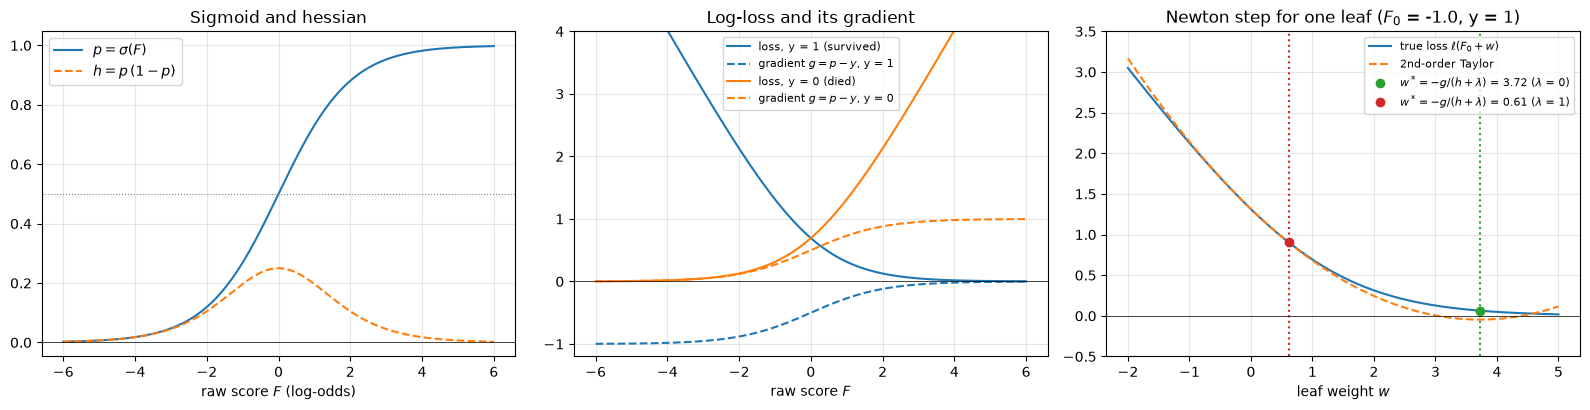

In [ ]:
# Plots of the sigmoid, the log-loss derivatives and the Newton step for one leaf weight
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def logloss(s, y):
    return -(y * np.log(sigmoid(s)) + (1 - y) * np.log(1 - sigmoid(s)))

F = np.linspace(-6, 6, 400)
p = sigmoid(F)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1) Sigmoid and its derivative p(1 - p), which is the hessian h
ax = axes[0]
ax.plot(F, p, label=r"$p = \sigma(F)$")
ax.plot(F, p * (1 - p), "--", label=r"$h = p\,(1 - p)$")
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
ax.set_title("Sigmoid and hessian")
ax.set_xlabel("raw score $F$ (log-odds)")
ax.legend()

# 2) Log-loss as a function of F, and its gradient g = p - y
ax = axes[1]
for y, name, color in [(1, "survived", "C0"), (0, "died", "C1")]:
    ax.plot(F, logloss(F, y), color=color, label=f"loss, y = {y} ({name})")
    ax.plot(F, p - y, "--", color=color, label=f"gradient $g = p - y$, y = {y}")
ax.set_ylim(-1.2, 4)
ax.set_title("Log-loss and its gradient")
ax.set_xlabel("raw score $F$")
ax.legend(fontsize=8)

# 3) Loss of one survivor (y = 1) around F0 and its 2nd-order Taylor approximation.
#    The parabola's minimum is w* = -g / (h + lambda). In a real leaf G and H are sums
#    over many samples, so lambda has less effect than in this single-sample example.
ax = axes[2]
F0, y = -1.0, 1
g, h = sigmoid(F0) - y, sigmoid(F0) * (1 - sigmoid(F0))
w = np.linspace(-2, 5, 400)
ax.plot(w, logloss(F0 + w, y), label=r"true loss $\ell(F_0 + w)$")
ax.plot(w, logloss(F0, y) + g * w + 0.5 * h * w**2, "--", label="2nd-order Taylor")
for lam, color in [(0, "C2"), (1, "C3")]:
    w_star = -g / (h + lam)
    ax.axvline(w_star, color=color, ls=":")
    ax.plot(w_star, logloss(F0 + w_star, y), "o", color=color,
            label=rf"$w^* = -g/(h + \lambda)$ = {w_star:.2f} ($\lambda$ = {lam})")
ax.set_ylim(-0.5, 3.5)
ax.set_title(f"Newton step for one leaf ($F_0$ = {F0}, y = 1)")
ax.set_xlabel("leaf weight $w$")
ax.legend(fontsize=8)

for ax in axes:
    ax.axhline(0, color="black", lw=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
!pip install pandas scikit-learn xgboost joblib

In [22]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt


In [23]:
def get_titanic_data():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    return pd.read_csv(url)

In [24]:
data = get_titanic_data()
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [25]:
target_col = "Survived"
categorical_cols = ["Pclass", "Sex", "Embarked"]
numeric_cols = ["Age", "SibSp", "Parch", "Fare"]
feature_cols = categorical_cols + numeric_cols

X = data[feature_cols]
y = data[target_col]

# Stratify to keep the same survival ratio in train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
# Preprocessing: impute missing values, scale numeric features,
# one-hot encode categorical features
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

# XGBoost: gradient-boosted decision trees
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

In [27]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



## Confusion matrix

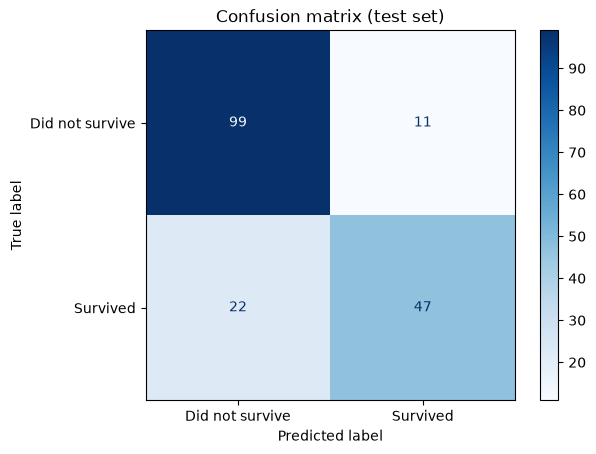

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Survived is imbalanced (~62%/38%); the confusion matrix shows the errors per class
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Did not survive", "Survived"]).plot(cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

## Feature importance

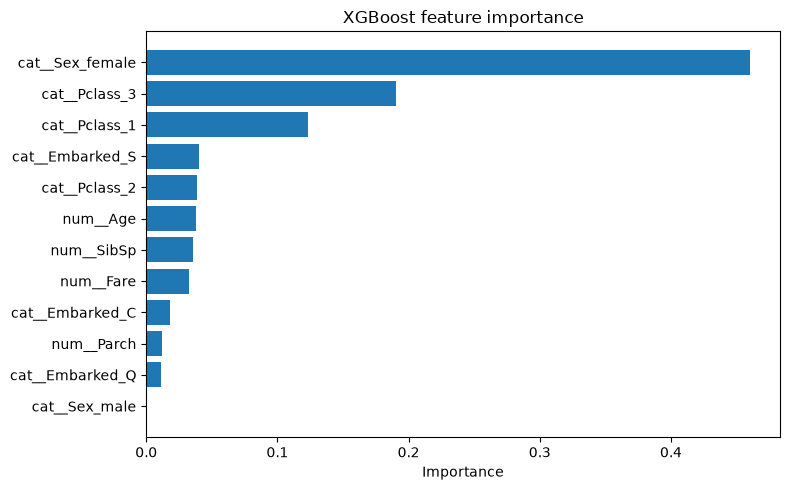

In [29]:
# Mean split gain of each feature (XGBoost's default importance_type)
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

In [30]:
# Save the fitted pipeline (preprocessing + model) to disk
joblib.dump(pipeline, "titanic_model.pkl")

['titanic_model.pkl']

In [31]:
def predict_survival(example):
    """Predict survival for a single passenger dict using the saved pipeline."""
    row = pd.DataFrame([example])[feature_cols]
    loaded_pipeline = joblib.load("titanic_model.pkl")
    pred = loaded_pipeline.predict(row)[0]
    proba = loaded_pipeline.predict_proba(row)[0]
    return {"Survived": bool(pred), "Probability": proba}

In [32]:
new_passenger = {
    "Pclass": 2,
    "Sex": "male",
    "Age": 29,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 71.25,
    "Embarked": "S",
}

result = predict_survival(new_passenger)
print(result)

{'Survived': False, 'Probability': array([0.8687407 , 0.13125934], dtype=float32)}


## Conclusão

A acurácia no teste (179 passageiros) foi 81,6%. Um classificador que sempre prevê "não sobreviveu" teria 61,5%. Com 179 exemplos, o erro padrão da acurácia é de cerca de 3 pontos percentuais; validação cruzada daria uma estimativa mais precisa.

O recall é 0,90 para passageiros que morreram e 0,68 para sobreviventes: 22 dos 69 sobreviventes do teste foram classificados como mortos. Reduzir o limiar de decisão para menos de 0,5 ou usar `scale_pos_weight` aumenta o recall dos sobreviventes e diminui a precisão.

Na importância por ganho, `Sex_female` tem 46% do total, seguida por `Pclass_3` e `Pclass_1`. `Sex_male` tem importância zero porque é o complemento de `Sex_female`, e as árvores usam apenas uma das duas colunas. No exemplo do fim do notebook, um homem de 29 anos da 2ª classe recebe probabilidade de sobrevivência de 0,13.

## Conclusion

Test accuracy (179 passengers) was 81.6%. A classifier that always predicts "did not survive" would get 61.5%. With 179 examples, the standard error of the accuracy is about 3 percentage points; cross-validation would give a more precise estimate.

Recall is 0.90 for passengers who died and 0.68 for survivors: 22 of the 69 survivors in the test set were classified as dead. Lowering the decision threshold below 0.5 or using `scale_pos_weight` increases survivor recall and lowers precision.

In the gain importance, `Sex_female` has 46% of the total, followed by `Pclass_3` and `Pclass_1`. `Sex_male` has zero importance because it is the complement of `Sex_female`, and the trees use only one of the two columns. In the example at the end of the notebook, a 29-year-old man in 2nd class gets a survival probability of 0.13.